# COT Hypothesis Test — Trend-Following Breakout

**Strategy:** N-day high/low breakout (long & short), entry at breakout level,  
stop at 2×ATR → breakeven at 1:1 R/R → trail at 2×ATR.  
Diversified portfolio across 20 lookbacks (5, 10, 15, …, 100) × all markets.

**H₀:** No COT Commercial Index filter improves this trend-following portfolio.  
**Method:** Hansen's SPA test (stationary bootstrap, 1 000 reps).  
**Decision rule:** p < 0.05 → reject H₀ (keep COT); otherwise → remove COT.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.getcwd())

from trend_following_test import (
    run_full_tf_test, LOOKBACKS, WALK_FORWARD_WINDOWS, INITIAL_CAPITAL,
)
from hypothesis_test import build_cot_grid, grid_label, grid_to_dataframe
from backtest_engine.data import load_cot_data

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="darkgrid")

print("Imports OK")

Imports OK


## 1. Load data

In [2]:
cot_df = load_cot_data(os.path.join(PROJECT_ROOT, "cot_data.json"))
markets = sorted(cot_df["Market"].unique().tolist())
print(f"Loaded {len(cot_df):,} rows across {len(markets)} markets")
print(f"Date range: {cot_df['Date'].min().date()} → {cot_df['Date'].max().date()}")

Loaded 51,893 rows across 48 markets
Date range: 2022-01-03 → 2026-04-02


## 2. Test design

In [3]:
cot_grid = build_cot_grid()

print(f"Lookback periods : {LOOKBACKS[0]}d to {LOOKBACKS[-1]}d  ({len(LOOKBACKS)} values, step 5)")
print(f"COT configs      : {len(cot_grid)} (1 base + {len(cot_grid)-1} COT variants)")
print(f"OOS windows      : {len(WALK_FORWARD_WINDOWS)}")
print(f"Total combos/win : {len(LOOKBACKS)} × {len(cot_grid)} = {len(LOOKBACKS)*len(cot_grid)}")
print(f"\nPortfolio capital : ${INITIAL_CAPITAL:,} × {len(LOOKBACKS)} lookbacks = ${INITIAL_CAPITAL*len(LOOKBACKS):,}")
print(f"\nWalk-forward windows:")
for w in WALK_FORWARD_WINDOWS:
    print(f"  {w['name']}  →  OOS: {w['test_start']} to {w['test_end']}")

Lookback periods : 5d to 100d  (20 values, step 5)
COT configs      : 50 (1 base + 49 COT variants)
OOS windows      : 3
Total combos/win : 20 × 50 = 1000

Portfolio capital : $30,000 × 20 lookbacks = $600,000

Walk-forward windows:
  Window 1 (Jan–Sep 2024)  →  OOS: 2024-01-01 to 2024-09-30
  Window 2 (Oct 2024–Jun 2025)  →  OOS: 2024-10-01 to 2025-06-30
  Window 3 (Jul 2025–Apr 2026)  →  OOS: 2025-07-01 to 2026-04-02


## 3. Run the hypothesis test

Runs 20 lookbacks × 50 COT configs × all markets × 3 OOS windows,  
then applies the SPA test on the diversified portfolio.

In [4]:
results = run_full_tf_test(
    cot_df, markets,
    windows=WALK_FORWARD_WINDOWS,
    cot_grid=cot_grid,
    lookbacks=LOOKBACKS,
    n_bootstrap=1000,
    verbose=True,
)

Trend-following test: 20 lookbacks × 50 COT configs = 1000 combos per window

Window 1 (Jan–Sep 2024)  |  OOS: 2024-01-01 → 2024-09-30
  Pre-computing indicators for all markets …


  48 markets with data
  Lookback   5d  (1/20)


  Lookback  10d  (2/20)


  Lookback  15d  (3/20)


  Lookback  20d  (4/20)


...

  Lookback  90d  (18/20)


  Lookback  95d  (19/20)


  Lookback 100d  (20/20)



Building aligned PnL matrix …
  OOS trading days: 578,  COT variants: 49

Running SPA test (1000 bootstrap replications) …
  p-value = 0.8760  →  FAIL TO REJECT H₀

Computing per-variant metrics …



Done.



## 4. SPA test result

In [5]:
spa = results["spa"]

print("=" * 60)
if spa["reject_h0"]:
    print("  VERDICT:  REJECT H₀")
    print("  At least one COT filter significantly improves")
    print("  the trend-following portfolio (p < 0.05).")
else:
    print("  VERDICT:  FAIL TO REJECT H₀")
    print("  No COT filter significantly improves the")
    print("  trend-following portfolio after correcting")
    print("  for 49 comparisons.")
    print("  Recommendation: REMOVE COT filters.")
print("=" * 60)
print(f"\n  SPA p-value (consistent): {spa['pvalue']:.4f}")
print(f"  SPA p-value (lower):      {spa['pvalue_lower']:.4f}")
print(f"  SPA p-value (upper):      {spa['pvalue_upper']:.4f}")
print(f"  Bootstrap replications:   {spa['n_bootstrap']}")
print(f"  Significance level:       0.05")

  VERDICT:  FAIL TO REJECT H₀
  No COT filter significantly improves the
  trend-following portfolio after correcting
  for 49 comparisons.
  Recommendation: REMOVE COT filters.

  SPA p-value (consistent): 0.8760
  SPA p-value (lower):      0.5170
  SPA p-value (upper):      0.8930
  Bootstrap replications:   1000
  Significance level:       0.05


## 5. Per-variant metrics (ranked by OOS Sharpe improvement)

In [6]:
mdf = results["metrics_df"].copy()
display_cols = [
    "label", "total_trades", "win_rate", "sharpe", "sharpe_diff",
    "max_dd_pct", "max_consec_losers", "profit_factor", "net_profit", "return_pct",
]
mdf = mdf[display_cols].reset_index(drop=True)
mdf.columns = [
    "Configuration", "Trades", "Win %", "Sharpe", "Sharpe Δ",
    "Max DD %", "Max Consec L", "PF", "Net Profit", "Return %",
]
mdf

,Configuration,Trades,Win %,Sharpe,Sharpe Δ,Max DD %,Max Consec L,PF,Net Profit,Return %
0,Lvl 60/40,6649,51.752,1.820,0.320,9.410,11,1.529,456734.790,76.122
1,Dir,9935,51.424,1.740,0.239,10.731,15,1.508,659900.740,109.983
2,Lvl 60/40 + Dir,4737,52.670,1.703,0.203,6.954,9,1.562,335580.200,55.930
3,Lvl 60/40 + ROC≥5,3790,53.852,1.659,0.159,4.264,9,1.591,279407.530,46.568
4,Lvl 60/40 + Dir + ROC≥5,3480,53.649,1.600,0.099,4.475,8,1.596,257069.740,42.845
5,ROC≥5,6587,52.831,1.597,0.096,6.411,8,1.419,347668.540,57.945
6,Lvl 80/20,4009,50.985,1.505,0.005,7.147,9,1.510,268771.100,44.795
7,Base (No COT),15436,49.249,1.501,0.000,14.223,10,1.364,769205.080,128.201
8,Dir + ROC≥5,5647,52.098,1.445,-0.055,5.789,9,1.376,271242.690,45.207
9,Lvl 70/30 + ROC≥5,3223,52.777,1.407,-0.093,5.873,7,1.509,211892.110,35.315


## 6. Sharpe ratio comparison

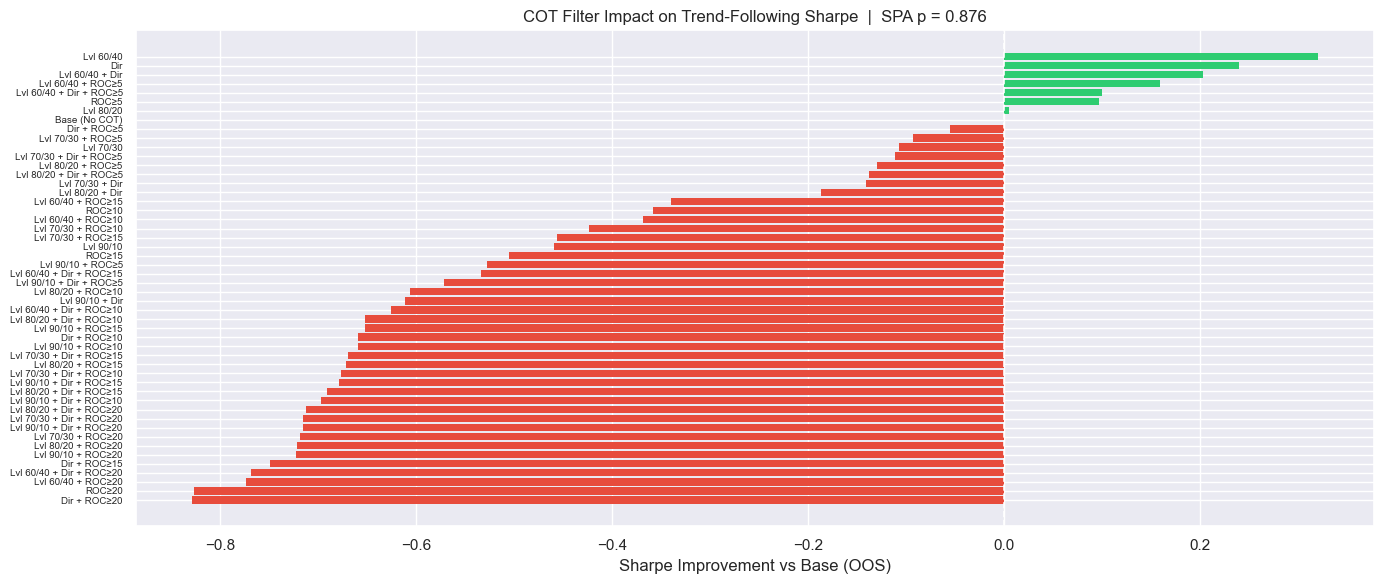

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
mdf_sorted = mdf.sort_values("Sharpe Δ", ascending=True)
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in mdf_sorted["Sharpe Δ"]]
ax.barh(range(len(mdf_sorted)), mdf_sorted["Sharpe Δ"], color=colors, edgecolor="none")
ax.set_yticks(range(len(mdf_sorted)))
ax.set_yticklabels(mdf_sorted["Configuration"], fontsize=7)
ax.axvline(0, color="white", linewidth=1.2, linestyle="--")
ax.set_xlabel("Sharpe Improvement vs Base (OOS)")
ax.set_title(f"COT Filter Impact on Trend-Following Sharpe  |  SPA p = {spa['pvalue']:.3f}")
plt.tight_layout()
plt.show()

## 7. Max drawdown comparison

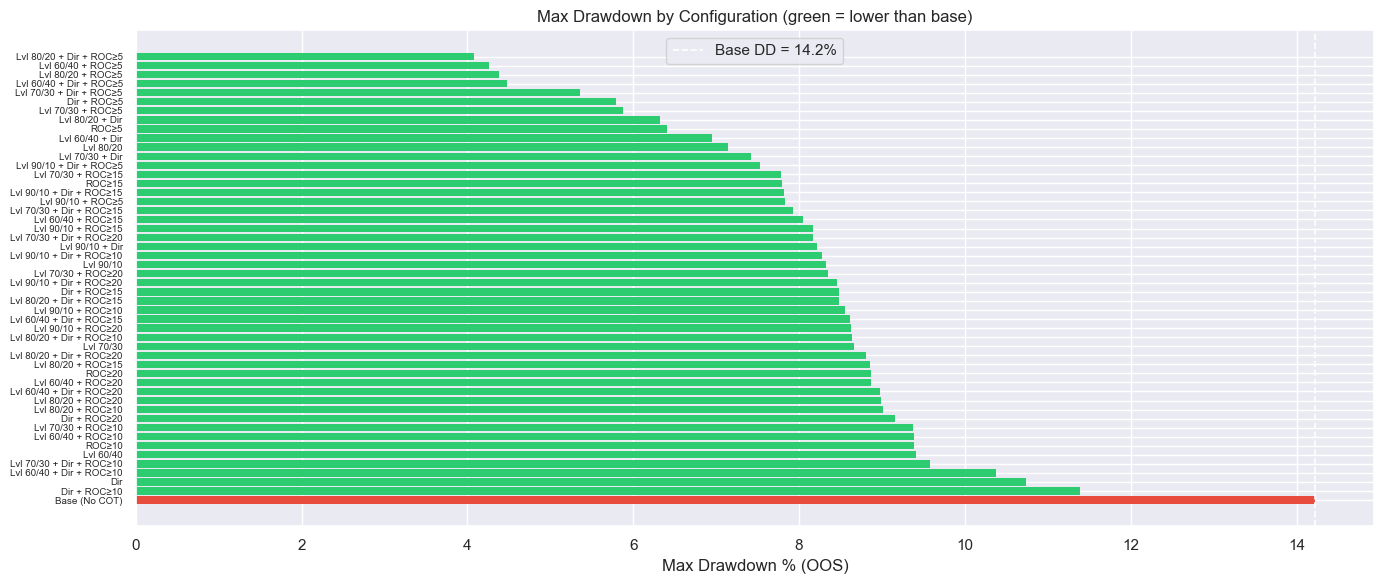

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
mdf_dd = mdf.sort_values("Max DD %", ascending=False)
base_dd = float(mdf[mdf["Configuration"] == "Base (No COT)"]["Max DD %"].values[0])
colors_dd = ["#2ecc71" if v < base_dd else "#e74c3c" for v in mdf_dd["Max DD %"]]
ax.barh(range(len(mdf_dd)), mdf_dd["Max DD %"], color=colors_dd, edgecolor="none")
ax.set_yticks(range(len(mdf_dd)))
ax.set_yticklabels(mdf_dd["Configuration"], fontsize=7)
ax.axvline(base_dd, color="white", linewidth=1.2, linestyle="--", label=f"Base DD = {base_dd:.1f}%")
ax.set_xlabel("Max Drawdown % (OOS)")
ax.set_title("Max Drawdown by Configuration (green = lower than base)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Sharpe vs Max Drawdown scatter

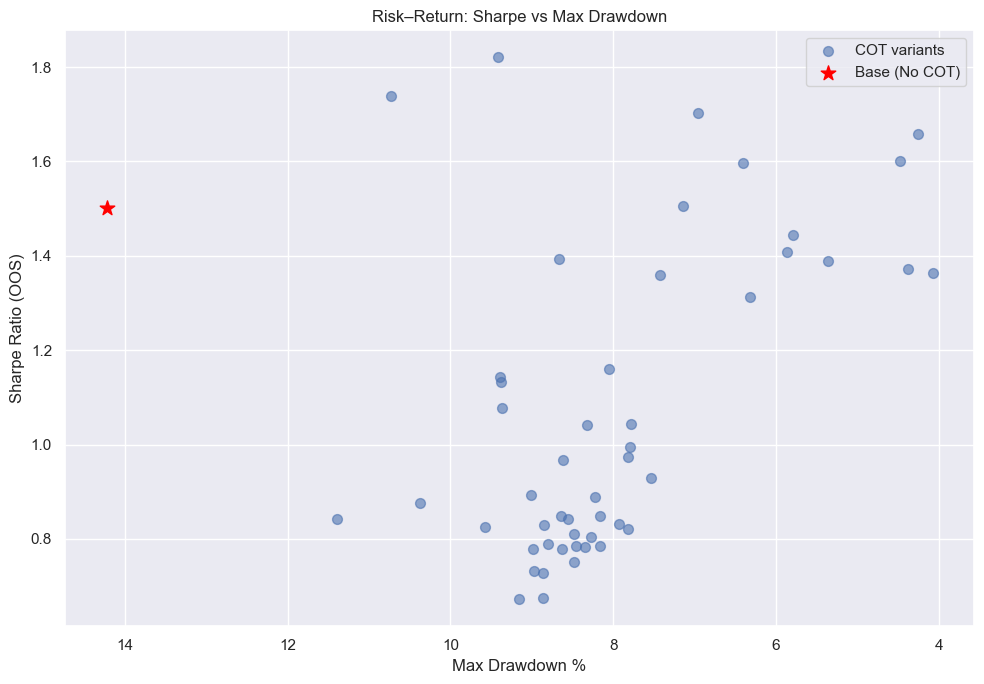

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
is_base = mdf["Configuration"] == "Base (No COT)"

ax.scatter(mdf.loc[~is_base, "Max DD %"], mdf.loc[~is_base, "Sharpe"],
           alpha=0.6, s=50, label="COT variants")
ax.scatter(mdf.loc[is_base, "Max DD %"], mdf.loc[is_base, "Sharpe"],
           color="red", s=120, zorder=5, marker="*", label="Base (No COT)")

ax.set_xlabel("Max Drawdown %")
ax.set_ylabel("Sharpe Ratio (OOS)")
ax.set_title("Risk–Return: Sharpe vs Max Drawdown")
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 9. COT filter heatmap

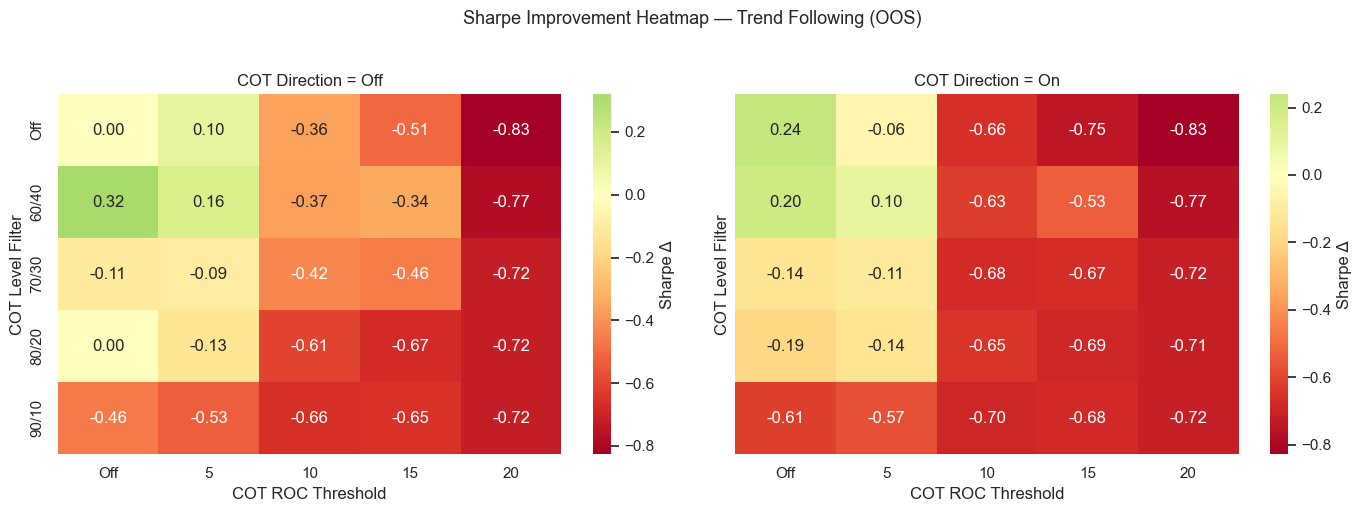

In [10]:
full_metrics = results["metrics_df"].copy()
grid = results["cot_grid"]

heat_rows = []
for _, row in full_metrics.iterrows():
    idx = int(row["config_idx"])
    p = grid[idx]
    heat_rows.append({
        "level": f"{p['cot_long']}/{p['cot_short']}" if p.get("cot_filter") else "Off",
        "direction": "On" if p.get("cot_direction_filter") else "Off",
        "roc": str(p["cot_roc_threshold"]) if p.get("cot_roc_filter") else "Off",
        "sharpe_diff": row["sharpe_diff"],
    })

heat_df = pd.DataFrame(heat_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, dir_val in enumerate(["Off", "On"]):
    sub = heat_df[heat_df["direction"] == dir_val]
    pivot = sub.pivot_table(index="level", columns="roc", values="sharpe_diff", aggfunc="mean")
    level_order = ["Off", "60/40", "70/30", "80/20", "90/10"]
    roc_order = ["Off", "5", "10", "15", "20"]
    pivot = pivot.reindex(index=[l for l in level_order if l in pivot.index],
                          columns=[r for r in roc_order if r in pivot.columns])
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                ax=axes[i], cbar_kws={"label": "Sharpe Δ"})
    axes[i].set_title(f"COT Direction = {dir_val}")
    axes[i].set_xlabel("COT ROC Threshold")
    axes[i].set_ylabel("COT Level Filter")

fig.suptitle("Sharpe Improvement Heatmap — Trend Following (OOS)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Per-window consistency

In [11]:
consistency = pd.DataFrame(results["per_window_best"])
print("Best-performing COT configuration per OOS window:\n")
consistency

Best-performing COT configuration per OOS window:



,window,best_config_idx,best_label,best_sharpe
0,Window 1 (Jan–Sep 2024),0,Base (No COT),1.749
1,Window 2 (Oct 2024–Jun 2025),15,Lvl 60/40 + Dir,1.368
2,Window 3 (Jul 2025–Apr 2026),11,Lvl 60/40 + ROC≥5,2.762


## 11. Cumulative OOS equity: Base vs best COT variant

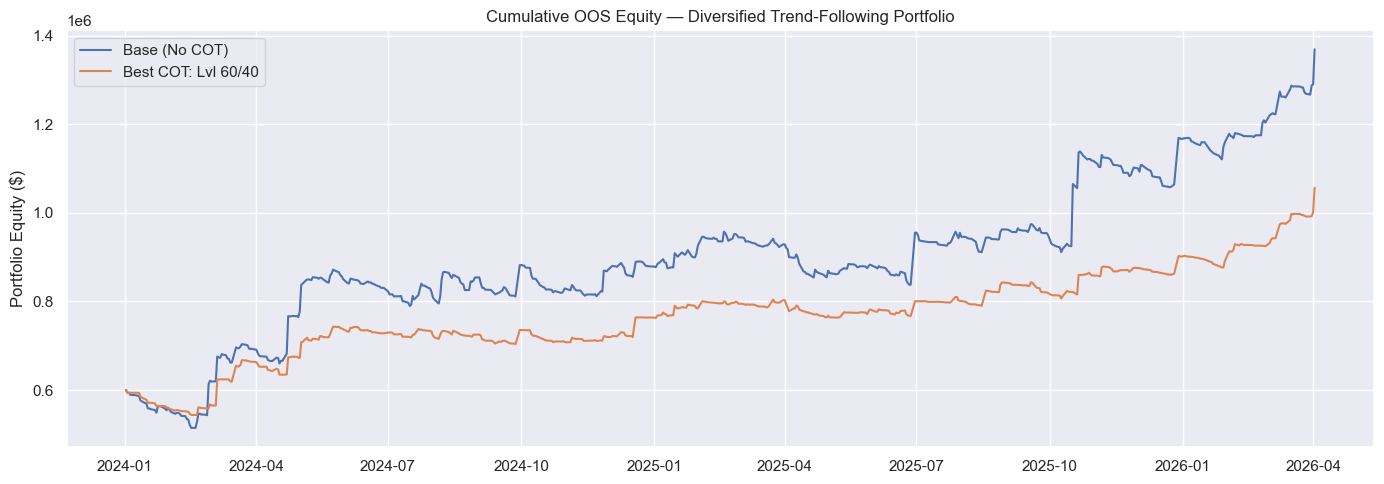

In [12]:
pcap = results["portfolio_capital"]
best_row = results["metrics_df"].iloc[0]
best_idx = int(best_row["config_idx"])
best_label = best_row["label"]

dates = results["dates"]
base_cum = pcap + np.cumsum(results["base_pnl"])

vi_list = results["variant_indices"]
if best_idx in vi_list:
    col = vi_list.index(best_idx)
    best_cum = pcap + np.cumsum(results["variant_pnl"][:, col])
else:
    best_cum = base_cum

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, base_cum, label="Base (No COT)", linewidth=1.5)
if best_idx != 0:
    ax.plot(dates, best_cum, label=f"Best COT: {best_label}", linewidth=1.5)
ax.set_ylabel("Portfolio Equity ($)")
ax.set_title("Cumulative OOS Equity — Diversified Trend-Following Portfolio")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Conclusion

In [13]:
base_row = results["metrics_df"][results["metrics_df"]["config_idx"] == 0].iloc[0]

print("=" * 60)
print("CONCLUSION — Trend-Following Breakout")
print("=" * 60)
print(f"\nPortfolio: {len(LOOKBACKS)} lookbacks (5–100d) × {len(markets)} markets")
print(f"OOS period: Jan 2024 – Apr 2026 (3 non-overlapping windows)")
print()
print(f"  Base Sharpe (OOS):         {base_row['sharpe']:.3f}")
print(f"  Base Max Drawdown:         {base_row['max_dd_pct']:.1f}%")
print(f"  Base Max Consec Losers:    {int(base_row['max_consec_losers'])}")
print(f"  Base Trades:               {int(base_row['total_trades']):,}")
print()
print(f"  Best COT variant:          {best_label}")
print(f"  Best Sharpe (OOS):         {best_row['sharpe']:.3f}")
print(f"  Best Max Drawdown:         {best_row['max_dd_pct']:.1f}%")
print(f"  Best Max Consec Losers:    {int(best_row['max_consec_losers'])}")
print(f"  Sharpe improvement:        {best_row['sharpe_diff']:+.3f}")
print()
print(f"  SPA p-value:               {spa['pvalue']:.4f}")
print()

if spa["reject_h0"]:
    print("REJECT H₀ — COT provides a statistically significant")
    print("improvement to trend-following after correcting for")
    print("49 simultaneous comparisons.")
    print(f"\nRecommended COT config: {best_label}")
else:
    print("FAIL TO REJECT H₀ — no statistically significant evidence")
    print("that any COT filter improves trend-following after")
    print("correcting for multiple comparisons.")
    print("\nRecommendation: REMOVE COT filters from trend-following.")

CONCLUSION — Trend-Following Breakout

Portfolio: 20 lookbacks (5–100d) × 48 markets
OOS period: Jan 2024 – Apr 2026 (3 non-overlapping windows)

  Base Sharpe (OOS):         1.501
  Base Max Drawdown:         14.2%
  Base Max Consec Losers:    10
  Base Trades:               15,436

  Best COT variant:          Lvl 60/40
  Best Sharpe (OOS):         1.820
  Best Max Drawdown:         9.4%
  Best Max Consec Losers:    11
  Sharpe improvement:        +0.320

  SPA p-value:               0.8760

FAIL TO REJECT H₀ — no statistically significant evidence
that any COT filter improves trend-following after
correcting for multiple comparisons.

Recommendation: REMOVE COT filters from trend-following.
